# Phase 2 — Data Preprocessing & Exploration

**Course:** AML-DL Project | **Authors:** Prerak Arya (230039), Saikiran Bompelliwar (230046)

This notebook loads the NSL-KDD dataset, applies preprocessing, creates the semi-supervised train/val/test split, and sets up curriculum learning. All subsequent model notebooks import the processed data from this pipeline.

---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
# Handle running from project root or Phase 2 directory
if os.path.isdir('utils'):
    sys.path.insert(0, '.')
elif os.path.isdir('Phase 2/utils'):
    os.chdir('Phase 2')
    sys.path.insert(0, '.')
else:
    raise RuntimeError("Cannot find utils/ directory. Run this notebook from the Phase 2 folder.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.config import SEED, DATA_DIR, DEVICE, RESULTS_DIR
from utils.data_loader import load_nslkdd, create_splits, setup_curriculum

print(f"Device: {DEVICE}")
print(f"Data directory: {DATA_DIR}")
print(f"Results directory: {RESULTS_DIR}")

Device: mps
Data directory: /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../../Phase 1/data
Results directory: /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../results


## 1. Load and Preprocess NSL-KDD

The NSL-KDD dataset contains 125,973 training records and 22,544 test records with 41 features each. We apply the same core preprocessing as Phase 1, with stricter leakage controls:
- Train-only categorical encoding for (protocol_type, service, flag); unseen test categories are mapped to -1
- Feature engineering: bytes_ratio, error_rate_diff, srv_diversity
- Remove zero-variance features

---

In [2]:
df_train, df_test, feature_cols = load_nslkdd()

print(f"Training set: {df_train.shape}")
print(f"Test set: {df_test.shape}")
print(f"Features: {len(feature_cols)}")
print(f"\nFeature list:")
for i, col in enumerate(feature_cols):
    print(f"  [{i+1:2d}] {col}")

Training set: (125973, 48)
Test set: (22544, 48)
Features: 43

Feature list:
  [ 1] duration
  [ 2] protocol_type
  [ 3] service
  [ 4] flag
  [ 5] src_bytes
  [ 6] dst_bytes
  [ 7] land
  [ 8] wrong_fragment
  [ 9] urgent
  [10] hot
  [11] num_failed_logins
  [12] logged_in
  [13] num_compromised
  [14] root_shell
  [15] su_attempted
  [16] num_root
  [17] num_file_creations
  [18] num_shells
  [19] num_access_files
  [20] is_host_login
  [21] is_guest_login
  [22] count
  [23] srv_count
  [24] serror_rate
  [25] srv_serror_rate
  [26] rerror_rate
  [27] srv_rerror_rate
  [28] same_srv_rate
  [29] diff_srv_rate
  [30] srv_diff_host_rate
  [31] dst_host_count
  [32] dst_host_srv_count
  [33] dst_host_same_srv_rate
  [34] dst_host_diff_srv_rate
  [35] dst_host_same_src_port_rate
  [36] dst_host_srv_diff_host_rate
  [37] dst_host_serror_rate
  [38] dst_host_srv_serror_rate
  [39] dst_host_rerror_rate
  [40] dst_host_srv_rerror_rate
  [41] bytes_ratio
  [42] error_rate_diff
  [43] srv_div

## 2. Dataset Statistics

### 2.1 Class Distribution

---

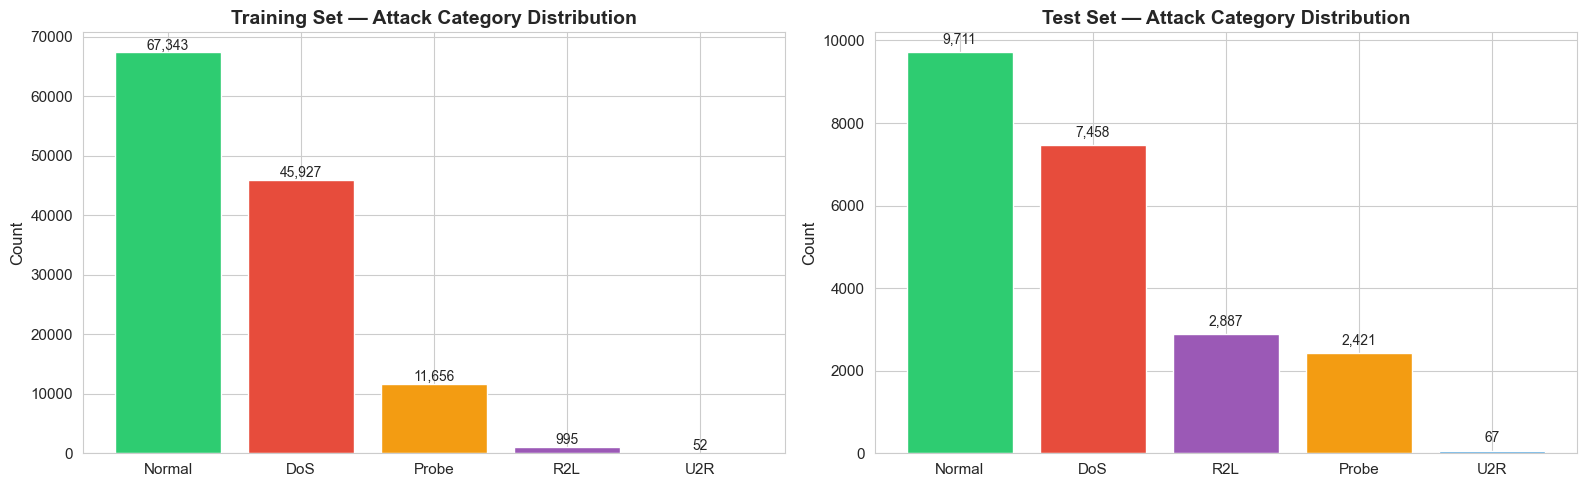


Training set distribution:
  Normal      67,343 (53.5%)
  DoS         45,927 (36.5%)
  Probe       11,656 (9.3%)
  R2L            995 (0.8%)
  U2R             52 (0.0%)

Test set distribution:
  Normal       9,711 (43.1%)
  DoS          7,458 (33.1%)
  R2L          2,887 (12.8%)
  Probe        2,421 (10.7%)
  U2R             67 (0.3%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Training set
train_counts = df_train['attack_cat'].value_counts()
colors = {'Normal': '#2ecc71', 'DoS': '#e74c3c', 'Probe': '#f39c12', 'R2L': '#9b59b6', 'U2R': '#3498db'}
axes[0].bar(train_counts.index, train_counts.values,
            color=[colors.get(x, '#95a5a6') for x in train_counts.index])
axes[0].set_title('Training Set — Attack Category Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (cat, cnt) in enumerate(train_counts.items()):
    axes[0].text(i, cnt + 500, f'{cnt:,}', ha='center', fontsize=10)

# Test set
test_counts = df_test['attack_cat'].value_counts()
axes[1].bar(test_counts.index, test_counts.values,
            color=[colors.get(x, '#95a5a6') for x in test_counts.index])
axes[1].set_title('Test Set — Attack Category Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for i, (cat, cnt) in enumerate(test_counts.items()):
    axes[1].text(i, cnt + 200, f'{cnt:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'class_distribution_phase2.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nTraining set distribution:")
for cat, cnt in train_counts.items():
    pct = cnt / len(df_train) * 100
    print(f"  {cat:<10} {cnt:>7,} ({pct:.1f}%)")

print("\nTest set distribution:")
for cat, cnt in test_counts.items():
    pct = cnt / len(df_test) * 100
    print(f"  {cat:<10} {cnt:>7,} ({pct:.1f}%)")

### 2.2 Feature Statistics

We examine feature distributions to understand data heterogeneity — this informs our preprocessing choices (StandardScaler) and loss weighting (inverse-variance).

---

Top 15 Most Discriminative Features (by mean difference / normal std):
Feature                         Normal Mean   Normal Std  Attack Mean      Ratio
------------------------------------------------------------------------------------------
wrong_fragment                        0.000        0.000        0.049  48746.376
srv_diversity                         5.153      544.945    29453.984     54.040
dst_host_srv_serror_rate              0.006        0.057        0.591     10.317
srv_serror_rate                       0.012        0.086        0.593      6.722
dst_host_serror_rate                  0.014        0.092        0.595      6.317
serror_rate                           0.013        0.094        0.596      6.181
same_srv_rate                         0.969        0.144        0.307      4.590
count                                22.518       54.026      154.850      2.449
flag                                  8.604        1.664        5.115      2.096
dst_host_same_srv_rate      

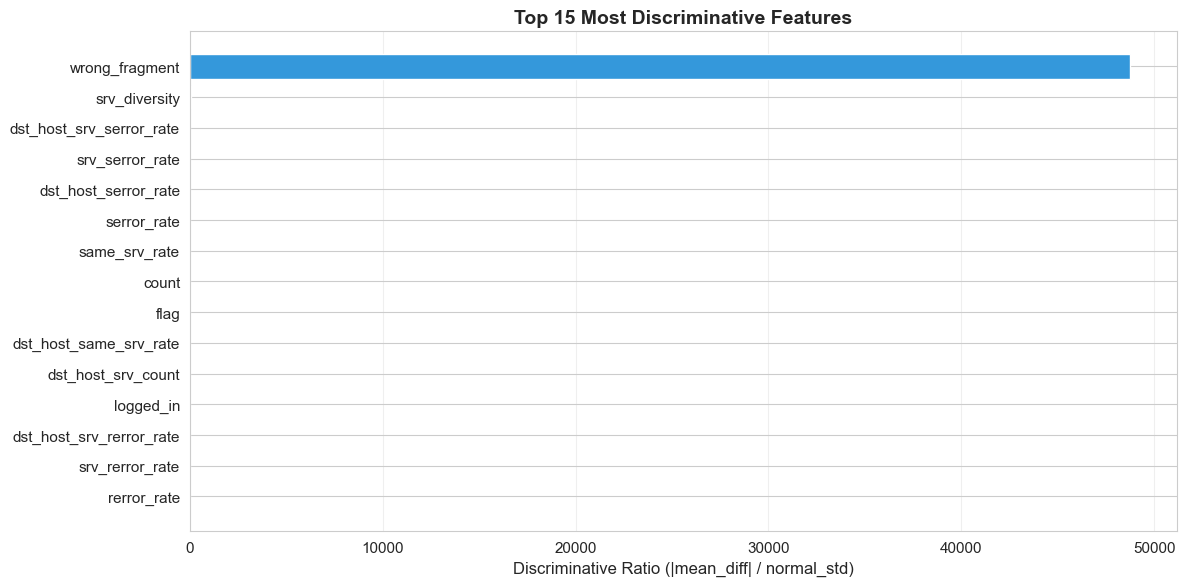

In [4]:
# Feature statistics for normal vs attack
normal_data = df_train[df_train['binary_label'] == 0][feature_cols]
attack_data = df_train[df_train['binary_label'] == 1][feature_cols]

stats = pd.DataFrame({
    'normal_mean': normal_data.mean(),
    'normal_std': normal_data.std(),
    'attack_mean': attack_data.mean(),
    'attack_std': attack_data.std(),
    'mean_diff': (attack_data.mean() - normal_data.mean()).abs(),
})
stats['discriminative_ratio'] = stats['mean_diff'] / (stats['normal_std'] + 1e-6)
stats = stats.sort_values('discriminative_ratio', ascending=False)

print("Top 15 Most Discriminative Features (by mean difference / normal std):")
print("=" * 90)
print(f"{'Feature':<30} {'Normal Mean':>12} {'Normal Std':>12} {'Attack Mean':>12} {'Ratio':>10}")
print("-" * 90)
for feat, row in stats.head(15).iterrows():
    print(f"{feat:<30} {row['normal_mean']:>12.3f} {row['normal_std']:>12.3f} "
          f"{row['attack_mean']:>12.3f} {row['discriminative_ratio']:>10.3f}")

# Top features bar chart
fig, ax = plt.subplots(figsize=(12, 6))
top15 = stats.head(15)
bars = ax.barh(range(len(top15)), top15['discriminative_ratio'], color='#3498db')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index)
ax.set_xlabel('Discriminative Ratio (|mean_diff| / normal_std)')
ax.set_title('Top 15 Most Discriminative Features', fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'discriminative_features.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Semi-Supervised Data Split

### Phase 1 Issue: Data Leakage
In Phase 1, hyperparameters were tuned directly on the test set — this constitutes data leakage and produces overly optimistic performance estimates.

### Phase 2 Fix: Proper Validation Split
We create a three-way split:
- **Train (normal only):** 80% of normal training records → model fitting
- **Validation (mixed):** 20% of normal + attack training records → threshold tuning
- **Test:** Held-out test set → final evaluation only

The scaler is fitted **exclusively on training normal data** to prevent information leakage from attack samples or test data into the feature normalisation.

---

In [5]:
splits = create_splits(df_train, df_test, feature_cols)

print("Data Split Summary")
print("=" * 60)
print(f"Train (normal only):  {splits['X_train_scaled'].shape}")
print(f"Val (normal):         {splits['X_val_normal_scaled'].shape}")
print(f"Val (mixed):          {splits['X_val_mixed_scaled'].shape}  "
      f"(Normal: {np.sum(splits['y_val_mixed']==0):,}, "
      f"Attack: {np.sum(splits['y_val_mixed']==1):,})")
print(f"Test:                 {splits['X_test_scaled'].shape}  "
      f"(Normal: {np.sum(splits['y_test']==0):,}, "
      f"Attack: {np.sum(splits['y_test']==1):,})")
print(f"\nInput dimension:      {splits['input_dim']}")
print(f"\nScaler verification (train-normal):")
print(f"  Mean ≈ 0: {splits['X_train_scaled'].mean():.6f}")
print(f"  Std  ≈ 1: {splits['X_train_scaled'].std():.4f}")

Data Split Summary
Train (normal only):  (53874, 43)
Val (normal):         (13469, 43)
Val (mixed):          (26938, 43)  (Normal: 13,469, Attack: 13,469)
Test:                 (22544, 43)  (Normal: 9,711, Attack: 12,833)

Input dimension:      43

Scaler verification (train-normal):
  Mean ≈ 0: -0.000000
  Std  ≈ 1: 0.9883


## 4. Scaled Feature Distribution

We visualise the scaled feature distributions to verify preprocessing and understand the data the models will receive.

---

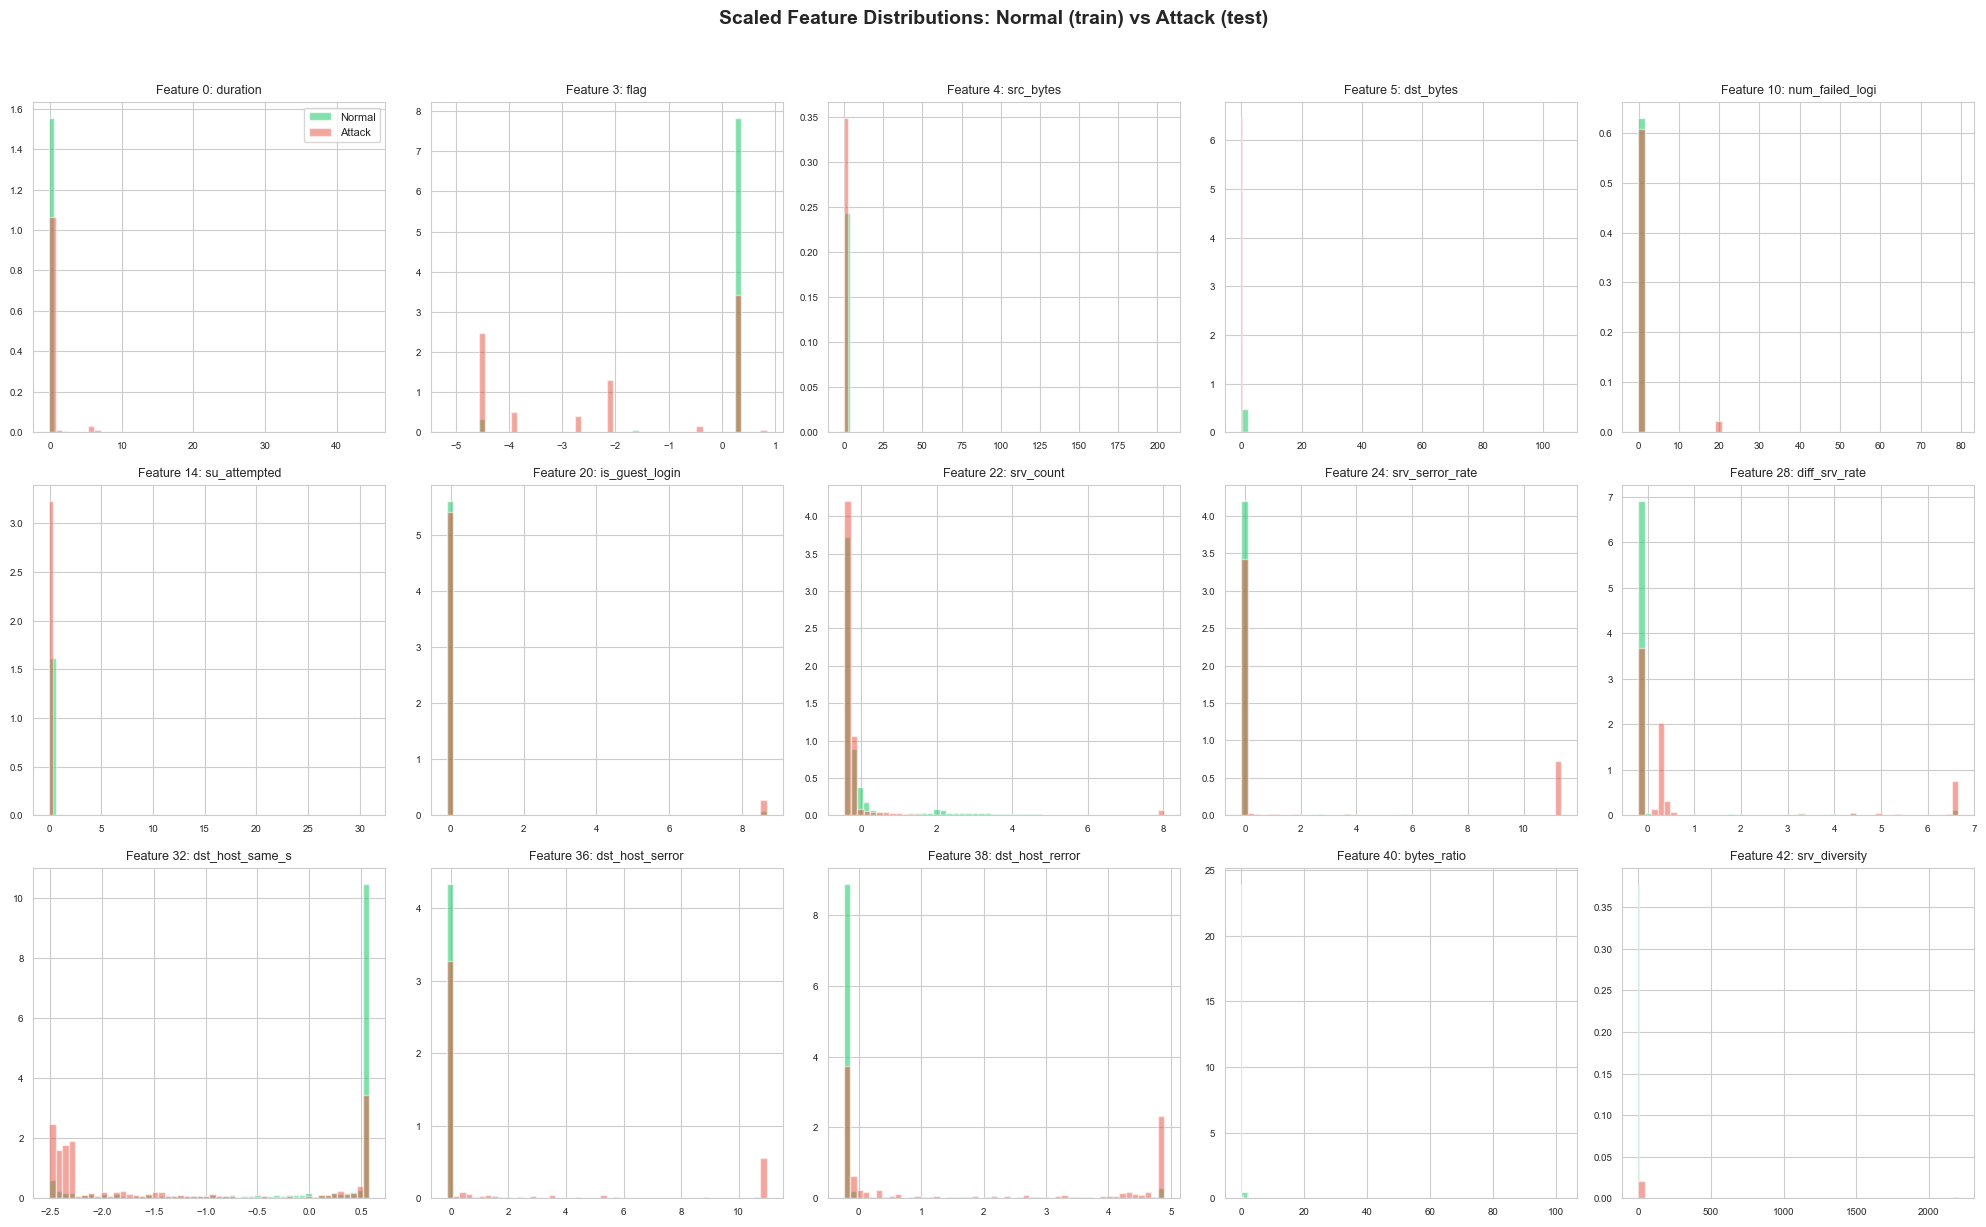

In [6]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.ravel()

# Pick 15 diverse features to visualise
viz_features = [0, 3, 4, 5, 10, 14, 20, 22, 24, 28, 32, 36, 38, 40, 42]
viz_features = [i for i in viz_features if i < splits['input_dim']]

for idx, feat_idx in enumerate(viz_features[:15]):
    ax = axes[idx]
    # Normal training data
    ax.hist(splits['X_train_scaled'][:, feat_idx], bins=50, alpha=0.6,
            color='#2ecc71', label='Normal', density=True)
    # Test attack data
    attack_mask = splits['y_test'] == 1
    ax.hist(splits['X_test_scaled'][attack_mask, feat_idx], bins=50, alpha=0.5,
            color='#e74c3c', label='Attack', density=True)
    ax.set_title(f'Feature {feat_idx}: {feature_cols[feat_idx][:15]}', fontsize=9)
    ax.tick_params(labelsize=7)
    if idx == 0:
        ax.legend(fontsize=8)

plt.suptitle('Scaled Feature Distributions: Normal (train) vs Attack (test)',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'feature_distributions_scaled.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Curriculum Learning Setup

We implement curriculum learning (Bengio et al., 2009) to improve training stability. Normal traffic samples are sorted by difficulty — using L2 distance from the centroid as a proxy — and training proceeds from easy (typical) to hard (edge-case) samples across three stages.

**Difficulty proxy:** L2 distance from the centroid of scaled normal training data. Samples close to the centroid are the most "typical" normal traffic; those far away are edge cases that may share characteristics with anomalous traffic.

---

Curriculum Learning Stages
  Easy — closest 33%        | 17,958 samples | dist: [1.30, 1.85, 2.01] | 15 epochs
  Medium — closest 66%      | 35,916 samples | dist: [1.30, 2.36, 4.10] | 15 epochs
  All — 100%                | 53,874 samples | dist: [1.30, 4.31, 232.29] | 20 epochs


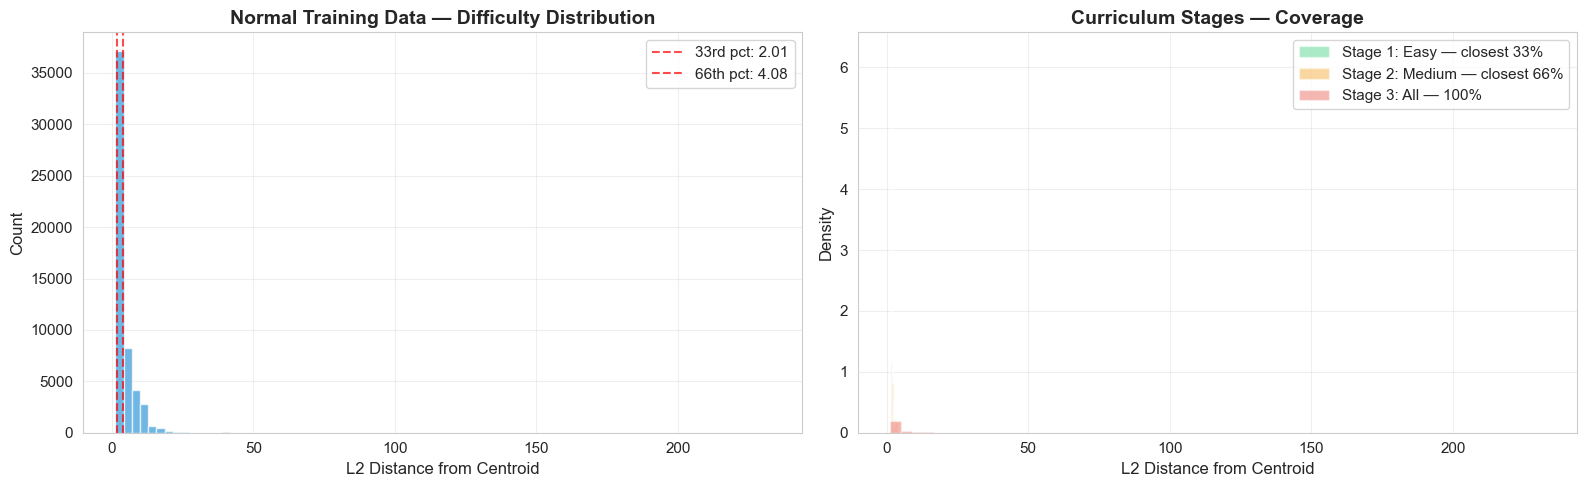

In [7]:
curriculum_stages, epochs_per_stage, distances = setup_curriculum(splits['X_train_scaled'])

print("Curriculum Learning Stages")
print("=" * 70)
for (name, idx), epochs in zip(curriculum_stages, epochs_per_stage):
    mean_d = distances[idx].mean()
    max_d = distances[idx].max()
    min_d = distances[idx].min()
    print(f"  {name:<25} | {len(idx):>6,} samples | "
          f"dist: [{min_d:.2f}, {mean_d:.2f}, {max_d:.2f}] | {epochs} epochs")

# Visualise difficulty distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(distances, bins=80, color='#3498db', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('L2 Distance from Centroid')
axes[0].set_ylabel('Count')
axes[0].set_title('Normal Training Data — Difficulty Distribution', fontweight='bold')
thresholds = [np.percentile(distances, 33), np.percentile(distances, 66)]
for t, label in zip(thresholds, ['33rd pct', '66th pct']):
    axes[0].axvline(t, color='red', linestyle='--', alpha=0.7, label=f'{label}: {t:.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Show how curriculum stages cover the distance space
stage_colors = ['#2ecc71', '#f39c12', '#e74c3c']
for i, ((name, idx), color) in enumerate(zip(curriculum_stages, stage_colors)):
    axes[1].hist(distances[idx], bins=60, alpha=0.4, color=color,
                 label=f'Stage {i+1}: {name}', density=True)
axes[1].set_xlabel('L2 Distance from Centroid')
axes[1].set_ylabel('Density')
axes[1].set_title('Curriculum Stages — Coverage', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'curriculum_setup.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Processed Data

We save the processed splits as `.npz` files so model notebooks can load them directly without re-running preprocessing.

---

In [8]:
import pickle

save_path = os.path.join(RESULTS_DIR, 'processed_data.npz')
np.savez(save_path,
         X_train_scaled=splits['X_train_scaled'],
         X_val_normal_scaled=splits['X_val_normal_scaled'],
         X_val_mixed_scaled=splits['X_val_mixed_scaled'],
         X_test_scaled=splits['X_test_scaled'],
         y_val_mixed=splits['y_val_mixed'],
         y_test=splits['y_test'],
         test_attack_cats=splits['test_attack_cats'])

scaler_path = os.path.join(RESULTS_DIR, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(splits['scaler'], f)

print(f"Saved processed data: {save_path}")
print(f"Saved scaler: {scaler_path}")
print(f"Input dimension: {splits['input_dim']}")
print("\nPreprocessing complete. Run model notebooks next.")

Saved processed data: /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../results/processed_data.npz
Saved scaler: /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../results/scaler.pkl
Input dimension: 43

Preprocessing complete. Run model notebooks next.
